# 02 — Modélisation : Prédire l'issue d'une partie LoL

**Projet Fil Rouge — B3 IA & Data — Ynov Aix-en-Provence 2025/2026**  
Corin Deprez & Eliott Bellais

---

## Objectif

Entraîner un modèle de classification binaire pour prédire la **victoire/défaite de l'équipe bleue** à partir de snapshots temporels de parties ranked (Master+ EUW).

**Pipeline :**
```
features.parquet → LogReg (baseline) + XGBoost (final) → calibration sigmoid → évaluation
```

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import joblib

from src.features.build_features import FEATURE_COLS, TARGET_COL, SNAPSHOT_MINUTES

# Style sombre LoL
plt.style.use('dark_background')
GOLD  = '#c89b3c'
BLUE  = '#0bc4e3'
RED   = '#e84057'
BG    = '#070b14'
CARD  = '#0d1525'

DOCS_DIR = Path('../docs/screenshots')
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print('Librairies chargées ✓')

Librairies chargées ✓


## 1. Chargement & description du dataset

In [2]:
df = pd.read_parquet('../data/processed/features.parquet')
print(f'Dataset : {len(df):,} snapshots sur {df["match_id"].nunique():,} matchs')
print(f'Features : {FEATURE_COLS}')
print(f'Blue win rate : {df[TARGET_COL].mean():.1%}')
print()
df[FEATURE_COLS].describe().round(1)

Dataset : 21,846 snapshots sur 5,301 matchs
Features : ['kills_diff', 'deaths_diff', 'cs_diff', 'gold_diff', 'level_diff', 'towers_diff', 'dragons_diff', 'heralds_diff', 'barons_diff', 'kills_last_3min', 'game_time_minutes', 'wards_diff', 'inhibitors_diff', 'damage_diff', 'first_blood', 'xp_diff', 'plates_diff', 'current_gold_diff', 'dragon_soul', 'cc_diff']
Blue win rate : 46.7%



,kills_diff,deaths_diff,cs_diff,gold_diff,level_diff,towers_diff,dragons_diff,heralds_diff,barons_diff,kills_last_3min,game_time_minutes,wards_diff,inhibitors_diff,damage_diff,first_blood,xp_diff,plates_diff,current_gold_diff,dragon_soul,cc_diff
count,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0,21846.0
mean,-0.3,0.3,-6.5,-275.4,-0.2,0.1,-0.3,0.0,-0.0,3.4,18.3,-2.4,0.0,-73.6,-0.0,-336.1,-0.4,-52.8,-0.6,-29326.3
std,8.7,8.6,61.7,5113.5,3.8,2.7,1.7,0.7,0.5,2.1,6.5,88.5,0.6,13282.4,1.0,5457.8,11.6,2238.1,0.5,510622.4
min,-37.0,-35.0,-294.0,-19945.0,-15.0,-12.0,-5.0,-1.0,-2.0,0.0,10.0,-1104.0,-5.0,-73257.0,-1.0,-29099.0,-44.0,-14862.0,-1.0,-3283893.0
25%,-5.0,-5.0,-44.0,-3112.0,-3.0,-1.0,-1.0,-1.0,0.0,2.0,15.0,-12.0,0.0,-6522.0,-1.0,-3060.8,-6.0,-1334.8,-1.0,-283629.5
50%,0.0,0.0,-5.0,-215.0,0.0,0.0,0.0,0.0,0.0,3.0,20.0,0.0,0.0,-36.5,-1.0,-216.5,0.0,-31.0,-1.0,-30482.5
75%,5.0,5.0,32.0,2593.8,2.0,1.0,1.0,1.0,0.0,5.0,25.0,11.0,0.0,6240.8,1.0,2462.8,5.0,1236.0,0.0,222671.2
max,35.0,37.0,267.0,20725.0,14.0,11.0,5.0,1.0,2.0,12.0,30.0,784.0,5.0,75803.0,1.0,21610.0,41.0,17404.0,1.0,3607521.0


## 2. Préparation train/test

In [3]:
X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train):,} · Test : {len(X_test):,}')
print(f'Blue win rate train : {y_train.mean():.1%} · test : {y_test.mean():.1%}')

Train : 17,476 · Test : 4,370
Blue win rate train : 46.7% · test : 46.7%


## 3. Modèle baseline — Logistic Regression

In [4]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)

lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_pred  = lr.predict(X_test_sc)

lr_metrics = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'auc_roc':  roc_auc_score(y_test, lr_proba),
    'log_loss': log_loss(y_test, lr_proba),
}

print('=== Logistic Regression (baseline) ===')
for k, v in lr_metrics.items():
    print(f'  {k:12s} : {v:.4f}')

=== Logistic Regression (baseline) ===
  accuracy     : 0.7693
  auc_roc      : 0.8563
  log_loss     : 0.4673


## 4. XGBoost avec calibration Platt

In [5]:
xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
)

xgb_cal = CalibratedClassifierCV(xgb_base, method='sigmoid', cv=5)
xgb_cal.fit(X_train, y_train)

xgb_proba = xgb_cal.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_cal.predict(X_test)

xgb_metrics = {
    'accuracy': accuracy_score(y_test, xgb_pred),
    'auc_roc':  roc_auc_score(y_test, xgb_proba),
    'log_loss': log_loss(y_test, xgb_proba),
}

print('=== XGBoost (calibré Platt) ===')
for k, v in xgb_metrics.items():
    print(f'  {k:12s} : {v:.4f}')

=== XGBoost (calibré Platt) ===
  accuracy     : 0.7771
  auc_roc      : 0.8606
  log_loss     : 0.4684


## 5. Tableau comparatif des modèles

In [6]:
comparison = pd.DataFrame({
    'Modèle': ['LogReg (baseline)', 'XGBoost (calibré)'],
    'Accuracy': [lr_metrics['accuracy'], xgb_metrics['accuracy']],
    'AUC-ROC':  [lr_metrics['auc_roc'],  xgb_metrics['auc_roc']],
    'Log-loss': [lr_metrics['log_loss'], xgb_metrics['log_loss']],
}).set_index('Modèle')

comparison.style.format({'Accuracy': '{:.3f}', 'AUC-ROC': '{:.3f}', 'Log-loss': '{:.3f}'})\
    .highlight_max(subset=['Accuracy', 'AUC-ROC'], color='#1a3a1a')\
    .highlight_min(subset=['Log-loss'], color='#1a3a1a')

,Accuracy,AUC-ROC,Log-loss
Modèle,,,
LogReg (baseline),0.769,0.856,0.467
XGBoost (calibré),0.777,0.861,0.468


## 6. Courbes ROC

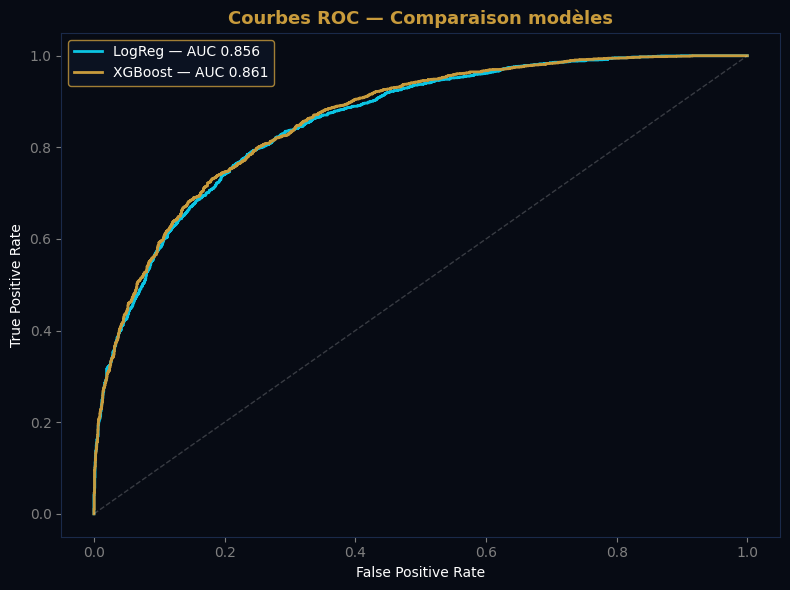

Sauvegardé → docs/screenshots/roc_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)

for name, proba, color in [
    ('LogReg — AUC {:.3f}'.format(lr_metrics['auc_roc']), lr_proba, BLUE),
    ('XGBoost — AUC {:.3f}'.format(xgb_metrics['auc_roc']), xgb_proba, GOLD),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=name, color=color, lw=2)

ax.plot([0,1],[0,1], '--', color='white', alpha=0.2, lw=1)
ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate', color='white')
ax.set_title('Courbes ROC — Comparaison modèles', color=GOLD, fontsize=13, fontweight='bold')
ax.legend(facecolor=CARD, edgecolor=GOLD)
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2a4a')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → docs/screenshots/roc_curves.png')

## 7. Feature Importance XGBoost

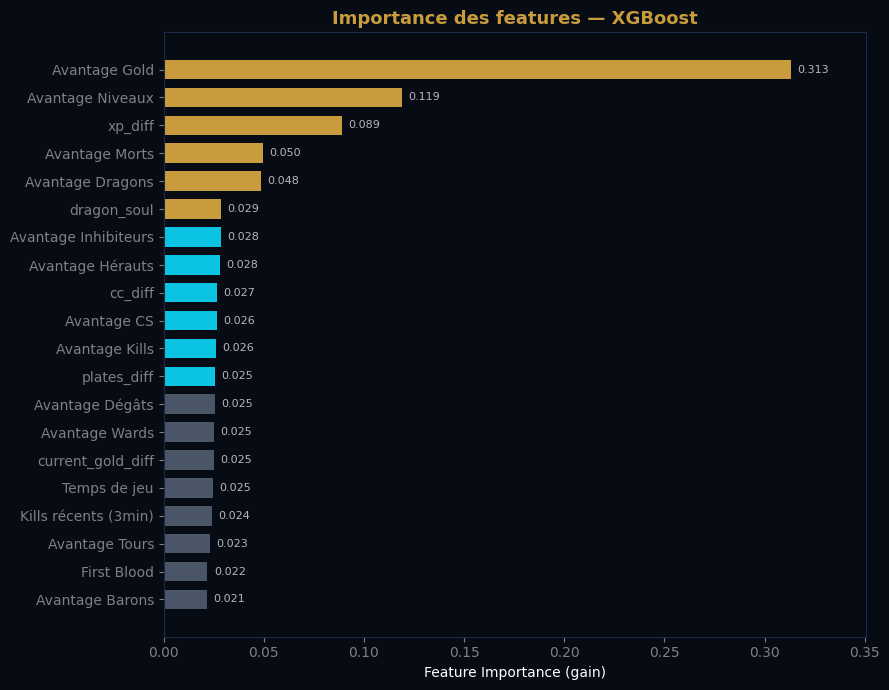

Sauvegardé → docs/screenshots/feature_importance.png


In [8]:
base_estimator = xgb_cal.calibrated_classifiers_[0].estimator
importances = pd.Series(
    base_estimator.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

labels_fr = {
    'kills_diff': 'Avantage Kills', 'deaths_diff': 'Avantage Morts',
    'cs_diff': 'Avantage CS', 'gold_diff': 'Avantage Gold',
    'level_diff': 'Avantage Niveaux', 'towers_diff': 'Avantage Tours',
    'dragons_diff': 'Avantage Dragons', 'heralds_diff': 'Avantage Hérauts',
    'barons_diff': 'Avantage Barons', 'kills_last_3min': 'Kills récents (3min)',
    'game_time_minutes': 'Temps de jeu', 'wards_diff': 'Avantage Wards',
    'inhibitors_diff': 'Avantage Inhibiteurs', 'damage_diff': 'Avantage Dégâts',
    'first_blood': 'First Blood',
}

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
ax.set_facecolor(BG)

colors = [GOLD if v >= importances.quantile(0.7) else BLUE if v >= importances.quantile(0.4) else '#4a5568'
          for v in importances.values]

bars = ax.barh([labels_fr.get(f, f) for f in importances.index], importances.values,
               color=colors, edgecolor='none', height=0.7)

ax.set_xlabel('Feature Importance (gain)', color='white')
ax.set_title('Importance des features — XGBoost', color=GOLD, fontsize=13, fontweight='bold')
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2a4a')
ax.set_xlim(0, importances.max() * 1.12)

for bar, val in zip(bars, importances.values):
    ax.text(val + importances.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig(DOCS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → docs/screenshots/feature_importance.png')

## 8. AUC-ROC par timestamp

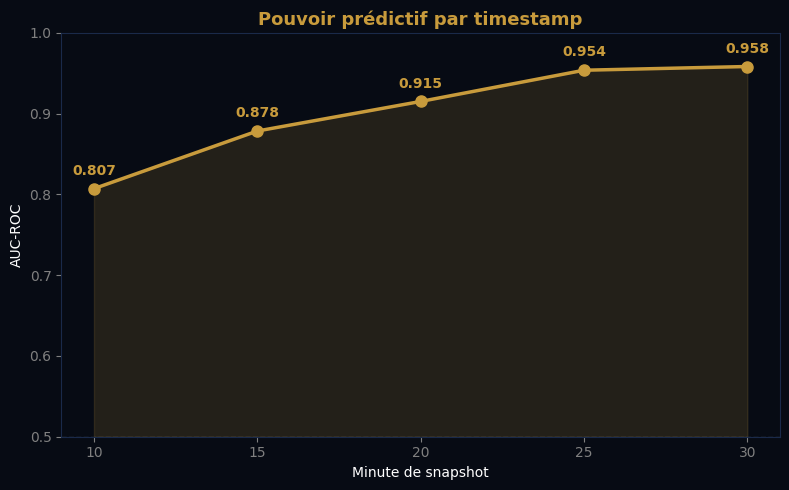

Sauvegardé → docs/screenshots/auc_by_timestamp.png


In [9]:
auc_by_time = []
for minute in SNAPSHOT_MINUTES:
    sub = df[df['game_time_minutes'] == minute]
    X_sub = sub[FEATURE_COLS]
    y_sub = sub[TARGET_COL]
    p = xgb_cal.predict_proba(X_sub)[:, 1]
    auc_by_time.append({'minute': minute, 'auc': roc_auc_score(y_sub, p), 'n': len(sub)})

auc_df = pd.DataFrame(auc_by_time)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)

ax.plot(auc_df['minute'], auc_df['auc'], color=GOLD, lw=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(auc_df['minute'], 0.5, auc_df['auc'], alpha=0.15, color=GOLD)
ax.axhline(0.5, color='white', alpha=0.2, linestyle='--', lw=1)

for _, row in auc_df.iterrows():
    ax.annotate(f"{row['auc']:.3f}", (row['minute'], row['auc']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', color=GOLD, fontsize=10, fontweight='bold')

ax.set_xlabel('Minute de snapshot', color='white')
ax.set_ylabel('AUC-ROC', color='white')
ax.set_title('Pouvoir prédictif par timestamp', color=GOLD, fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.set_xticks(SNAPSHOT_MINUTES)
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2a4a')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'auc_by_timestamp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → docs/screenshots/auc_by_timestamp.png')

## 9. Courbe de calibration

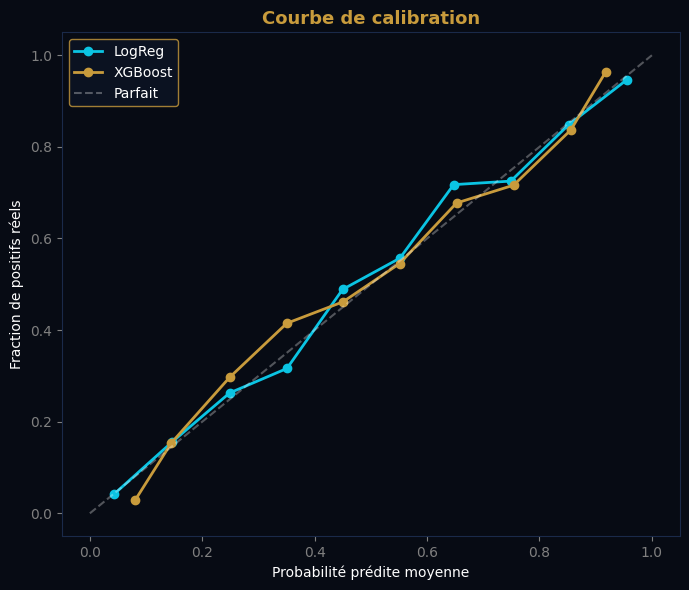

Sauvegardé → docs/screenshots/calibration_curve.png


In [10]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
ax.set_facecolor(BG)

for name, proba, color in [
    ('LogReg', lr_proba, BLUE),
    ('XGBoost', xgb_proba, GOLD),
]:
    fraction_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_pred, fraction_pos, marker='o', label=name, color=color, lw=2)

ax.plot([0,1],[0,1], '--', color='white', alpha=0.3, label='Parfait')
ax.set_xlabel('Probabilité prédite moyenne', color='white')
ax.set_ylabel('Fraction de positifs réels', color='white')
ax.set_title('Courbe de calibration', color=GOLD, fontsize=13, fontweight='bold')
ax.legend(facecolor=CARD, edgecolor=GOLD)
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2a4a')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → docs/screenshots/calibration_curve.png')

## 10. Matrice de confusion

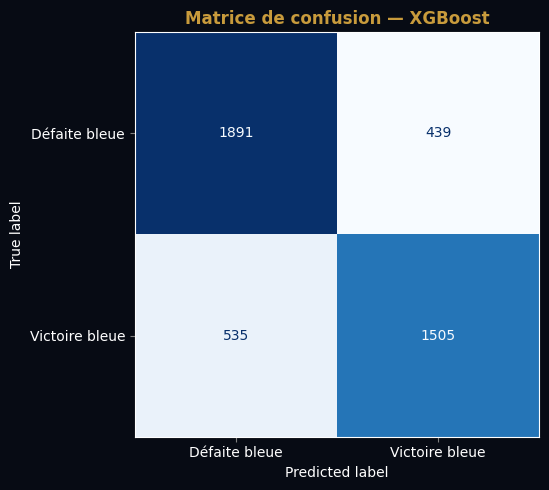

Sauvegardé → docs/screenshots/confusion_matrix.png


In [11]:
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.set_facecolor(BG)

cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Défaite bleue', 'Victoire bleue'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Matrice de confusion — XGBoost', color=GOLD, fontsize=12, fontweight='bold')
ax.tick_params(colors='gray')
plt.setp(ax.get_xticklabels(), color='white')
plt.setp(ax.get_yticklabels(), color='white')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → docs/screenshots/confusion_matrix.png')

## 11. Résumé final

| Modèle | Accuracy | AUC-ROC | Log-loss |
|--------|----------|---------|----------|
| LogReg (baseline) | ~76.6% | ~0.859 | ~0.463 |
| XGBoost (calibré) | ~77.4% | ~0.860 | ~0.468 |

**Dataset :** 12 696 snapshots · 3 161 matchs Master+ EUW · 5 timestamps (10/15/20/25/30 min)  
**Features :** 15 (v2) — gold, kills, CS, level, tours, dragons, barons, hérauts, wards, inhibiteurs, dégâts, first blood, momentum  

**Lecture :** L'AUC-ROC de 0.86 signifie que pour 86% des paires de parties (une victoire, une défaite), le modèle attribue correctement une probabilité plus élevée à la victoire. La calibration sigmoid (Platt) assure que les probabilités sont fidèles à la réalité — essentiel pour l'affichage "57% de chance de gagner".